# 'Hamiltonian-Driven Architectures for Non-Markovian Quantum Reservoir Computing' analysis
The aim of this notebook is to reproduce the results of the paper 'Hamiltonian-Driven Architectures for Non-Markovian Quantum Reservoir Computing' by Daiki Sasaki et. al, and to extend the methodology to include time-dependent dynamics to input time series values into the reservoir. The hope is that this will provide superior performance due the potential advantages of time-dependent dynamics over repeated state updates

## 1. Imports

In [1]:
from qsim.dynamics import Dynamics, RK4Propagator, GKSLGenerator, HamiltonianGenerator, DiagonalPropagator, ExponentialPropagator, LiouvillianGenerator
from qsim.lin_alg import sigmaX, sigmaY, sigmaZ, I, TOperator, sigmaMinus, Operator, Vector, DiscreteTOperator
from qsim.logging import Logger
from qsim.state import ObservableDetector, DensityMatrix
from qsim.lin_alg.transforms import vectorise, unvectorise
from numbers import Real
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import dill

## 2. Time Series Configuration

In [2]:
from typing import Protocol


class Series(Protocol):

    def __call__(self, index: int) -> Real: ...

class TimeSeries:
    def __init__(self, s: Series, delta_t: Real):
        self._s = s
        self._delta_t = delta_t

    def __call__(self, t) -> Real:
        index = int((t + 10e-10) // self._delta_t)
        return self._s(index)

In [3]:
class UniformRandomSeries(Series):

    def __init__(self, n):
        self._s = np.random.rand(n)

    def __call__(self, index: int):
        if index >= self._s.shape[0]:
            raise ValueError(f'Index {index} exceeds series length of {self._s.shape[0]}')
        return self._s[index]

In [4]:
s = UniformRandomSeries(100)

In [5]:
ts = TimeSeries(s, 0.3)

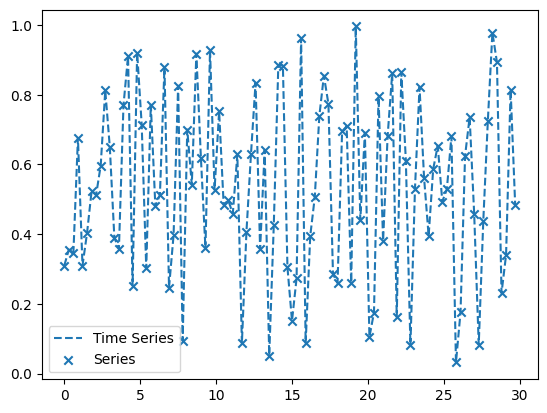

In [6]:
times = np.linspace(0,29.7, 100)
fig, ax = plt.subplots()
ax.plot(times, [ts(t) for t in times], label='Time Series', linestyle = '--')
ax.scatter(0.3 * np.arange(100), [s(index) for index in np.arange(100)], label='Series', marker='x')
ax.legend()
plt.show()

## 3. Global Parameters and functions

Global parameters and time series input

In [7]:
n_evolve_steps = 5000
n_steps = n_evolve_steps + 100
s = UniformRandomSeries(n_steps)

# save (pickle) an object
#with open("s.pkl", "wb") as f:
#    dill.dump(s, f)

# load (unpickle) it
with open("s.pkl", "rb") as f:
    s = dill.load(f)

In [8]:
delta_t_ds = 0.5

In [9]:

J_0 = 1
time_multiplexing = 50

regimes = {'markov': (10, 0.01), 'intermediate': (1,1), 'nonmarkov': (0.01, 10)}



Constructing transverse ising Hamiltonian

In [10]:
def baseH(h_res, h_env, j_res, j_env, g, N_res, N_env):
    ops = []
    N=N_env + N_res
    for j in range(N_res):
        ops.append(h_res * TOperator.from_static(sigmaZ).changeHilbertSpace((2,)*N, send_to_sites=(j,)))
        for i in range(j):
            ops.append(np.random.uniform(-j_res, j_res) * sigmaX.tensor(sigmaX).changeHilbertSpace((2,) * N, send_to_sites=(i,j), base_dims=(2,2)))

    for j in range(N_res, N):
        ops.append(h_env * TOperator.from_static(sigmaZ).changeHilbertSpace((2,)*N, send_to_sites=(j,)))
        for i in range(N_res, j):
            ops.append(np.random.uniform(-j_env, j_env) * sigmaX.tensor(sigmaX).changeHilbertSpace((2,) * N, send_to_sites=(i,j), base_dims=(2,2)))

    for i in range(N_res):
        for j in range(N_res, N):
            ops.append(np.random.uniform(-g, g) * sigmaZ.tensor(sigmaZ).changeHilbertSpace((2,) * N, send_to_sites=(i,j), base_dims=(2,2)))
 
    return reduce(lambda x,y:x+y, ops)

Standard logging setup

In [11]:
def singleQubitDetector(node: int, op: Operator, N):
    return ObservableDetector(op, dims=(2,) * N, target_sites=(node,))

def dualQubitDetector(node1: int, op1: Operator, node2: int, op2: Operator, N):
    return ObservableDetector(op1.tensor(op2), dims=(2,) * N, target_sites=(node1, node2))

Setting up loggers for first and second moment Pauli observables

In [12]:
def getLogger(N, N_res):
    detectors = []
    paulis = [sigmaZ]

    for i in range(N_res):
        for pauli in paulis:
            detectors.append(singleQubitDetector(i, pauli, N))

    #for pauli in paulis:
    #    for i in range(N_res):
    #        for j in range(i):
    #            if i != j:
    #                detectors.append(dualQubitDetector(i, pauli, j, pauli))
    
    log = Logger(detectors)
    return log

Dynamics check function

In [13]:
def checkLegit(state: DensityMatrix, t):
    if not state.isLegitimate():
        print('Invalid Density Matrix')
        if round(state.trace().real,5) != 1:
            print(f'Trace: {round(state.trace().real,5)}')
        if not state.isSelfAdjoint():
            print('State not self-adjoint')
        if not state.isSemiPositive():
            print(f'State min eig: {min(np.linalg.eigvals(state.matrix))}')

## 4. Daiki Sasaki Model

### 4.1 DS Dynamics Setup

Setting injection timestep length

In [14]:
N_res_ds = 4
N_env_ds = 3
N_ds = N_res_ds + N_env_ds
state = np.zeros(shape=(2**N_ds, 2**N_ds)).astype(np.complex128)
state[0][0] = 1
rho0_ds = DensityMatrix(state)

Creating dynamics generator

In [15]:
dynamics_ds = []

for alpha, beta in regimes.values():
    prop_fn = ExponentialPropagator(callbacks=[checkLegit])
    H = baseH(h_res= J_0/2, h_env=alpha * J_0, j_res=J_0, j_env=alpha*J_0, g=beta*J_0, N_res = N_res_ds, N_env=N_env_ds)(0)
    gen_fn = HamiltonianGenerator(H)
    dyn_fn = Dynamics(prop_fn, gen_fn)
    log_fn = getLogger(N_ds, N_res_ds)
    dyn_fn.addCallback(log_fn.log)
    dynamics_ds.append((dyn_fn, log_fn))

Function to encode timeseries value into state

In [16]:
def dsEncode(state: DensityMatrix, s: Real):
    state = state.partialTrace(dims=(2,)*N_ds, reduce_to_sites=tuple([i for i in range(1, N_ds)]))
    state = DensityMatrix(np.array([[1-s, (s-s**2)**0.5], [(s-s**2)**0.5, s]])).tensor(state)
    return state

### 4.2 FN Sample Evolution

In [17]:
dyn_ds, log_ds = dynamics_ds[1]
log_ds.clear()
num_steps = 10
steps = np.arange(1, num_steps + 1)
state_t = dsEncode(rho0_ds, s(0))
t0 = 0
num_sub_steps = 30
ts = np.round(delta_t_ds/num_sub_steps,6)
for step in tqdm(steps):
    for sub_step in range(num_sub_steps):
        state_t = dyn_ds.evolve(state_t, ts=[t0+ts], t0=t0)
        t0 += ts
        t0 = np.round(t0, 8)
    state_t = dsEncode(state_t, s(step))

  0%|          | 0/10 [00:00<?, ?it/s]

In [18]:
dynamics_ds[1][0]._gen._unitary_cache

{np.float64(0.016667): Operator(dim=128)}

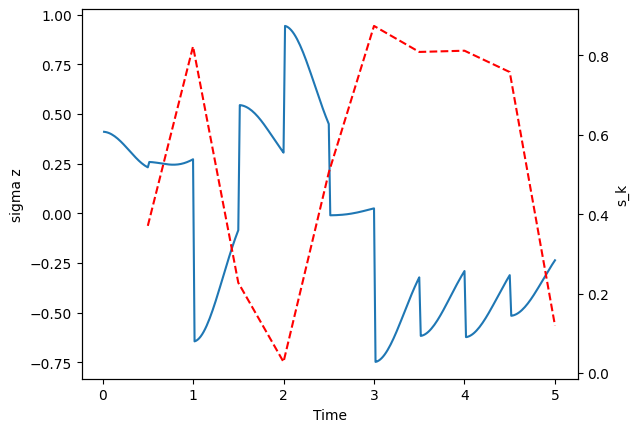

In [19]:
log_ds = dynamics_ds[1][1]

fig, ax1 = plt.subplots()

measure_times = ts * np.arange(1, num_steps * num_sub_steps + 1)

# First y-axis
ax1.plot(measure_times, log_ds.observable_log[log_ds._detectors[0]].values())
ax1.set_xlabel("Time")
ax1.set_ylabel("sigma z")

# Second y-axis
ax2 = ax1.twinx()
ax2.plot(delta_t_ds*steps, [s(t) for t in steps], linestyle='--', color='r')
ax2.set_ylabel("s_k")

plt.show()

### 4.3 FN Full Evolution

In [107]:
for dyn_ds, log_ds in dynamics_ds:
    log_ds.clear()
    num_steps = n_evolve_steps
    steps = np.arange(1, num_steps + 1)
    state_t = dsEncode(rho0_ds, s(0))
    t0 = 0
    for step in tqdm(steps):
        state_t = dyn_ds.evolve(state_t, ts=[t0+np.round(delta_t_ds * (i+1)/time_multiplexing,5) for i in range(time_multiplexing)], t0=t0)
        t0 += delta_t_ds
        state_t = dsEncode(state_t, s(step))

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

# save (pickle) an object
#with open("dynamics_ds.pkl", "wb") as f:
#    dill.dump(dynamics_ds, f)

# load (unpickle) it
with open("dynamics_ds.pkl", "rb") as f:
    dynamics_ds = dill.load(f)

## 5. Continuous Dissipation Model

### 5.1 CD Dynamics Setup

In [20]:
N_res_cd = 3
N_env_cd = 2
N_cd = N_res_cd + N_env_cd
state = np.zeros(shape=(2**N_cd, 2**N_cd)).astype(np.complex128)
state[0][0] = 1
rho0_cd = DensityMatrix(state)

Defining relevant parameter combinations

In [21]:
cd_gammas = [0.01, 0.1, 1]

Constructing Hamiltonian and jump operators

In [22]:
def variableXDrive(node: int, s_k: Series, h: float):
    H: TOperator =  (lambda t: h * (1+s_k(t))) * TOperator.from_static(sigmaX)
    return H.changeHilbertSpace((2,)*N_cd, send_to_sites=(node,))

In [23]:
def dampingChannel(node: int, gamma: float):
    L: Operator = sigmaMinus
    return (gamma**0.5) * L.changeHilbertSpace((2,)*N_cd, send_to_sites=(node,))

Setting up dynamics, including constructing time series, setting up Hamiltonian with drive and damping and configuring logging

In [24]:
dynamics_cd = []

for gamma in cd_gammas:
    for alpha, beta in regimes.values():
  
        H_locals = []
        Ls = []
        s_k = TimeSeries(s, delta_t_ds)

        for i in range(N_res_cd):
            H_locals.append(variableXDrive(i, s_k, J_0/2))
            Ls.append(dampingChannel(i, gamma))

        H_cd = reduce(lambda x,y :x+y, H_locals + [baseH(h_res= J_0/2, h_env=alpha * J_0, j_res=J_0, j_env=alpha*J_0, g=beta*J_0, N_res = N_res_cd, N_env = N_env_cd)])
        H_cd = DiscreteTOperator(H_cd, intervals = ((i+1) * delta_t_ds for i in range(n_steps)))
        prop_cd = RK4Propagator()
        gen_cd = GKSLGenerator(H_cd, Ls)

        dyn_cd = Dynamics(prop_cd, gen_cd,callbacks=[checkLegit])

        log_cd = getLogger(N_cd, N_res_cd)
        dyn_cd.addCallback(log_cd.log)
        dynamics_cd.append((dyn_cd, log_cd, (alpha, beta, gamma)))

In [45]:
import math
ns = range(20)
ts = np.logspace(-4, -0.5, 8)
ts

array([1.00000000e-04, 3.16227766e-04, 1.00000000e-03, 3.16227766e-03,
       1.00000000e-02, 3.16227766e-02, 1.00000000e-01, 3.16227766e-01])

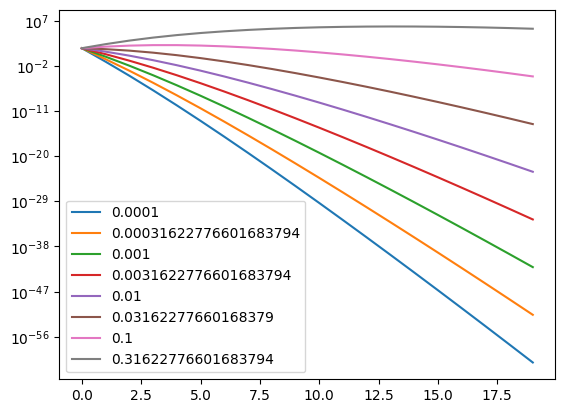

In [49]:


for t in ts:
    plt.plot(ns, [np.linalg.norm(np.linalg.matrix_power(LiouvillianGenerator.fromGKSL(dynamics_cd[0][0]._gen).L(0).matrix * t, n)/math.factorial(n)) for n in ns])

plt.legend(ts)
plt.yscale('log')
plt.show()

### 5.2 CD Sample Evolution

import copy

n_steps = 1000

s_k = TimeSeries(s, delta_t_ds)
measure_times = 0.05*delta_t_ds*(np.arange(501, n_steps + 501))

dyn_cd, log_cd, params = dynamics_cd[2]

dyn_cd._prop = IVPPropagator(solver='RK45', atol=1e-10, rtol=1e-8)
log_cd.clear()
dyn_cd.evolve(rho0_cd, ts=measure_times, verbose=1)





dyn_cd2 = copy.deepcopy(dyn_cd)
dyn_cd2._callbacks = [checkLegit]
log_cd2 = getLogger(N_cd, N_res_cd)
dyn_cd2.addCallback(log_cd2.log)

dyn_cd2._prop = IVPPropagator(solver='RK45', atol=1e-6, rtol=1e-6)
log_cd2.clear()
dyn_cd2.evolve(rho0_cd, ts=measure_times, verbose=1)

det = 0

fig, ax = plt.subplots(dpi=200)
ax.plot(measure_times, log_cd.observable_log[log_cd._detectors[det]].values(), label='Accurate')
ax.set_xlabel("Time")
ax.set_ylabel("sigma z")

ax.plot(measure_times, log_cd2.observable_log[log_cd2._detectors[det]].values(), label='Low Resolution')
ax.set_xlabel("Time")
ax.set_ylabel("sigma z")

# Second y-axis
ax2 = ax.twinx()
ax2.plot(measure_times, [s_k(t) for t in measure_times], linestyle='--', color='r')
ax2.set_ylabel("s_k")

ax.set_title(f'Params = {params}')

ax.legend()

In [47]:

n_steps = 100

for dyn_cd, log_cd, params in dynamics_cd:
    s_k = TimeSeries(s, delta_t_ds)

    log_cd.clear()

    measure_times = 0.05*delta_t_ds*(np.arange(501, n_steps + 501))
    dyn_cd.evolve(rho0_cd, ts=measure_times, verbose=1)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

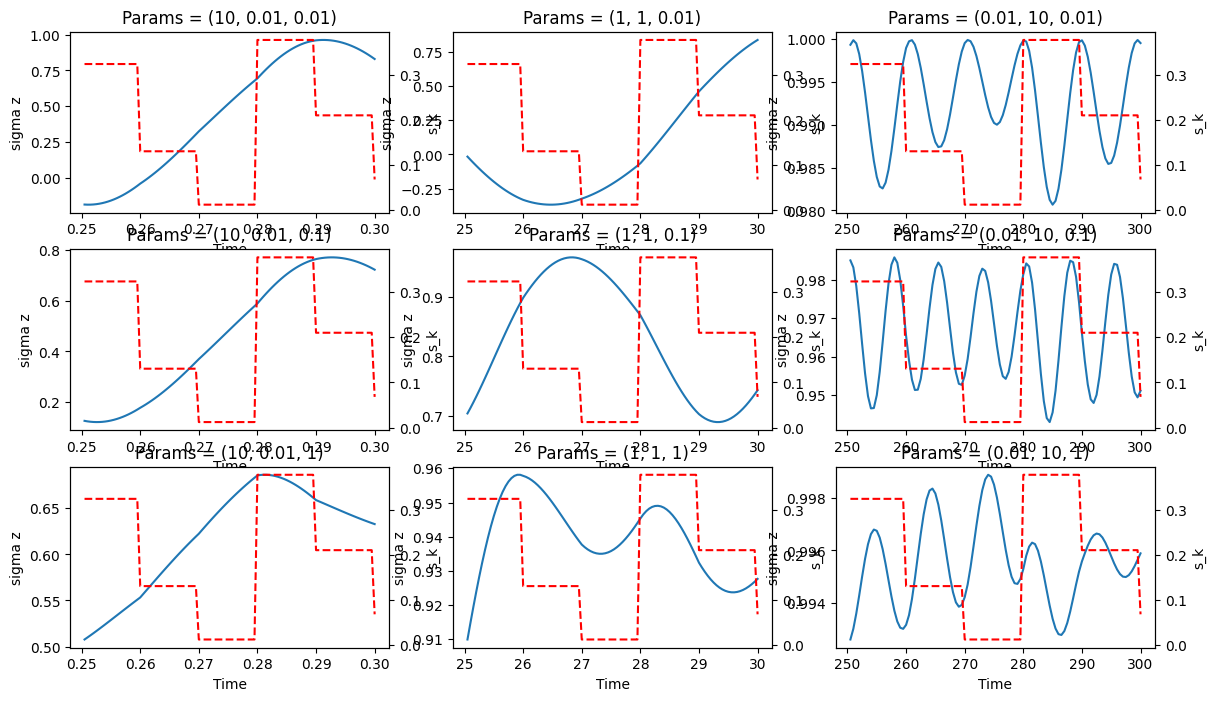

In [49]:
fig, axs = plt.subplots(3,3, figsize=(14,8))

# First y-axis
for i in range(3):
    for j in range(3):
        ax = axs[i][j]
        dyn_cd, log_cd, params = dynamics_cd[3*i + j]
        s_k = TimeSeries(s, params[1])
        measure_times = 0.05*params[1]*(np.arange(501, n_steps + 501))
        ax.plot(measure_times, log_cd.observable_log[log_cd._detectors[0]].values())
        ax.set_xlabel("Time")
        ax.set_ylabel("sigma z")

        # Second y-axis
        ax2 = ax.twinx()
        ax2.plot(measure_times, [s_k(t) for t in measure_times], linestyle='--', color='r')
        ax2.set_ylabel("s_k")

        ax.set_title(f'Params = {params}')

### 5.3 CD Full Evolution

In [50]:
for dyn_cd, log_cd, params in dynamics_cd:
    log_cd.clear()
    measure_times = (delta_t_ds/time_multiplexing)*(np.arange(1, (n_evolve_steps * time_multiplexing) + 1))
    dyn_cd.evolve(rho0_cd, ts=measure_times, verbose=1)

  0%|          | 0/250000 [00:00<?, ?it/s]

  0%|          | 0/250000 [00:00<?, ?it/s]

  0%|          | 0/250000 [00:00<?, ?it/s]

  0%|          | 0/250000 [00:00<?, ?it/s]

  0%|          | 0/250000 [00:00<?, ?it/s]

  0%|          | 0/250000 [00:00<?, ?it/s]

  0%|          | 0/250000 [00:00<?, ?it/s]

  0%|          | 0/250000 [00:00<?, ?it/s]

  0%|          | 0/250000 [00:00<?, ?it/s]

# save (pickle) an object
#with open("dynamics_cd.pkl", "wb") as f:
#    dill.dump(dynamics_cd, f)

# load (unpickle) it
with open("dynamics_cd.pkl", "rb") as f:
    dynamics_cd = dill.load(f)

## 6. CD QRC Analysis

Defining training and testing data ranges

In [108]:
tr_idxs = np.arange(1000,4000)
te_idxs = np.arange(4000, 5000)

### 6.1 Target Functions

#### 6.1.1 STM function

In [109]:
def STM(tau: int, s: Series):
    return lambda t: s(t-tau)

In [110]:
import math


def STM_exp(tau: int, s: Series):
    return lambda t: math.e**s(t-tau)

Visualising STM

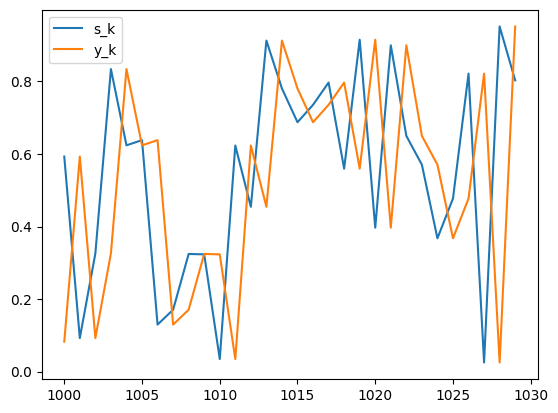

In [111]:
tau=1
y_k = STM(tau, s)

plt.plot(tr_idxs[:30], [s(i) for i in tr_idxs[:30]], label = 's_k')
plt.plot(tr_idxs[:30], [y_k(i) for i in tr_idxs[:30]], label = 'y_k')
plt.legend()

#### 6.1.2 NARMA function

In [112]:
def narma(n: int, s_k: Series):
    def narma_n(k: int, depth: int = 10, computed: dict = None):
        if not computed:
            computed = {}
        if depth > 0:
            depth -= 1
            if k-1 not in computed.keys():
                computed[k-1] = narma_n(k-1, depth, computed)
            for j in range(1, n + 1):
                if k-j not in computed.keys():
                    computed[k-j] = narma_n(k-j, depth, computed) 
            return computed[k-1]*(0.3 + 0.05 * sum([computed[k-j] for j in range(1, n + 1)])) + 1.5 * s_k(k-n)*s_k(k-1) + 0.1
        else:
            return 0
    return narma_n

Assessing necessary depth - 40 appears to be sufficient for n <= 20

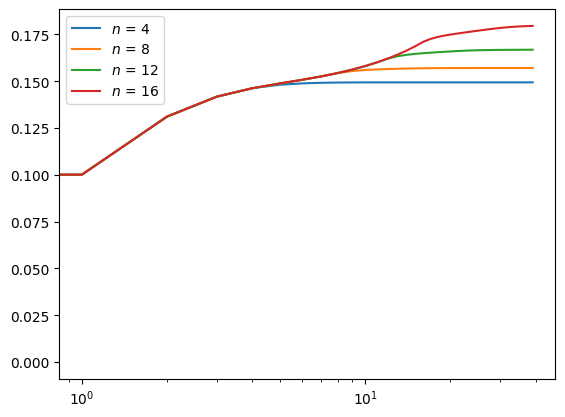

In [113]:
depths = np.arange(40)

for n in np.arange(1, 5) * 4:
    narma_n = narma(n, lambda i: s(i)/50)
    plt.plot(depths, [narma_n(1000, depth) for depth in (depths)], label=r'$n$ = ' + str(n))

plt.legend()
plt.xscale('log')

Visualising segment of NARMA for n = 10

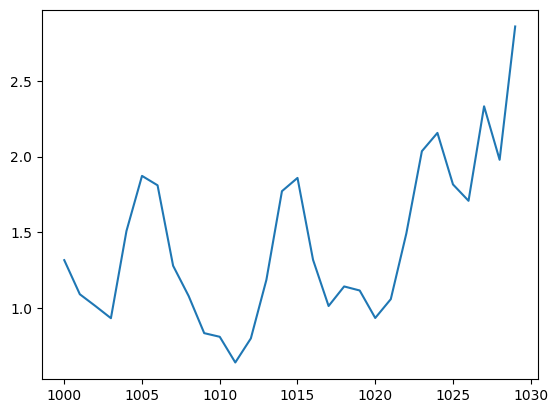

In [114]:
narma_10 = narma(10, s)
plt.plot(tr_idxs[:30], [narma_10(i) for i in tr_idxs[:30]])

#### 6.1.3 Parity Function

In [115]:
def parity(tau, s):
    return lambda k: sum([s(k-j) for j in range(1, tau+1)]) % 2

Visualising parity function

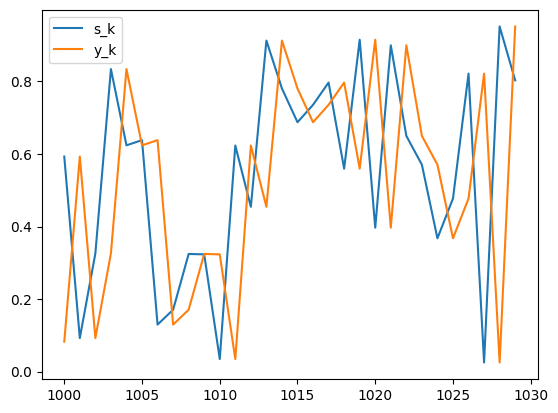

In [116]:
y_k = parity(tau, s)

plt.plot(tr_idxs[:30], [s(i) for i in tr_idxs[:30]], label = 's_k')
plt.plot(tr_idxs[:30], [y_k(i) for i in tr_idxs[:30]], label = 'y_k')
plt.legend()

#### 6.1.4 Polynomial Task

In [117]:
def polynomial(n, s, order = 1):
    return lambda k: reduce(lambda x,y: x * y, [s(k-j)**order for j in range(1, n+1)])

In [118]:
def polynomial_exp(n, s):
    return lambda k: reduce(lambda x,y: x * y, [math.e**s(k-j) for j in range(1, n+1)])

Visualising polynomial function

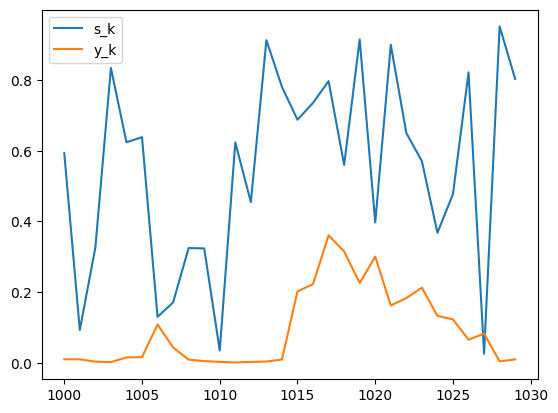

In [119]:
y_k = polynomial(4, s)

plt.plot(tr_idxs[:30], [s(i) for i in tr_idxs[:30]], label = 's_k')
plt.plot(tr_idxs[:30], [y_k(i) for i in tr_idxs[:30]], label = 'y_k')
plt.legend()

#### 6.1.5 Tomography task

In [120]:
import numpy as np

def density_matrix_to_vec(rho: np.ndarray) -> np.ndarray:
    """
    Flatten a Hermitian density matrix into a 1D real vector containing
    all unique real and imaginary parts.

    Layout of the returned vector:
        [ diag (N),
          Re(upper off-diagonal) (N*(N-1)/2),
          Im(upper off-diagonal) (N*(N-1)/2) ]

    Parameters
    ----------
    rho : np.ndarray, shape (N, N), complex
        Hermitian density matrix.

    Returns
    -------
    vec : np.ndarray, shape (N**2,), float
        Flattened representation.
    """
    rho = np.asarray(rho)
    if rho.ndim != 2 or rho.shape[0] != rho.shape[1]:
        raise ValueError("rho must be a square 2D array")

    N = rho.shape[0]

    # Optional sanity check for Hermiticity
    if not np.allclose(rho, rho.conj().T):
        raise ValueError("rho is not Hermitian within numerical tolerance")

    # Diagonal (purely real for a density matrix)
    diag = rho.diagonal().real

    # Upper-triangular off-diagonal entries
    iu = np.triu_indices(N, k=1)
    upper = rho[iu]
    real_upper = upper.real
    imag_upper = upper.imag

    # Concatenate into a single real vector
    vec = np.concatenate([diag, real_upper, imag_upper]).astype(float)
    return vec


def vec_to_density_matrix(vec: np.ndarray) -> np.ndarray:
    """
    Reconstruct a Hermitian matrix from the flattened real vector produced
    by `density_matrix_to_vec`.

    Parameters
    ----------
    vec : np.ndarray, shape (N**2,), float
        Flattened representation.

    Returns
    -------
    rho : np.ndarray, shape (N, N), complex
        Reconstructed Hermitian matrix.
    """
    vec = np.asarray(vec, dtype=float).ravel()

    # Infer dimension N from length N**2
    N_float = np.sqrt(vec.size)
    N = int(round(N_float))
    if N * N != vec.size:
        raise ValueError("Length of vec must be a perfect square (N**2).")

    # Number of unique off-diagonal entries in the upper triangle
    K = N * (N - 1) // 2
    expected_len = N + 2 * K
    if vec.size != expected_len:
        raise ValueError(
            f"Invalid vector length {vec.size} for any Hermitian N; "
            f"expected N + 2 * N*(N-1)/2 = N**2."
        )

    # Slice out components
    diag = vec[:N]
    real_upper = vec[N:N + K]
    imag_upper = vec[N + K:]

    # Build matrix
    rho = np.zeros((N, N), dtype=complex)
    np.fill_diagonal(rho, diag)

    iu = np.triu_indices(N, k=1)
    rho[iu] = real_upper + 1j * imag_upper
    # Fill lower triangle by Hermitian symmetry
    rho[(iu[1], iu[0])] = rho[iu].conj()

    return rho



In [121]:
def tomography(n, s):
    def tomography_n(k):
        s_vals = [s(k - j) for j in range(1, n+1)]
        state = DensityMatrix(np.array([[1-s_vals[0], (s_vals[0]-s_vals[0]**2)**0.5], [(s_vals[0]-s_vals[0]**2)**0.5, s_vals[0]]]))

        for s_val in s_vals[1:]:
            state = state.tensor(DensityMatrix(np.array([[1-s_val, (s_val-s_val**2)**0.5], [(s_val-s_val**2)**0.5, s_val]])))

        return density_matrix_to_vec(state.state)
    return tomography_n

### 6.2 Evaluating Performance

In [122]:
class LinearRegression:

    def fit(self, x, y):
        vals = np.linalg.pinv(np.vstack([x.T, np.ones(x.shape[0])])).T @ y
        self.coeff = vals[:-1]
        self.c = vals[-1] 
        return self

    def predict(self, x):
        return x @ self.coeff + self.c

In [123]:
def flatten_row_blocks(A, x):
    n, m = A.shape

    if n % x != 0:
        raise ValueError(f"Number of rows ({n}) must be divisible by x ({x})")

    return A.reshape(n // x, x * m)

In [124]:
x_tr_fn = {}
x_tr_cd = {}

x_te_fn = {}
x_te_cd = {}

for params, dynamics in zip(regimes.values(), dynamics_ds):
    log_fn = dynamics[1]
    x_fn = np.vstack([list(log_fn.observable_log[detector].values()) for detector in log_fn._detectors])
    x_fn = flatten_row_blocks(x_fn.T, time_multiplexing).T
    x_tr_fn[params] = x_fn.T[tr_idxs[0]:tr_idxs[-1]+1]
    x_te_fn[params] = x_fn.T[te_idxs[0]:te_idxs[-1]+1]


for dyn, log, params in dynamics_cd:
    x_cd = np.vstack([list(log.observable_log[detector].values()) for detector in log._detectors])
    x_cd = flatten_row_blocks(x_cd.T, time_multiplexing).T
    x_tr_cd[params] = x_cd.T[tr_idxs[0]:tr_idxs[-1]+1]
    x_te_cd[params] = x_cd.T[te_idxs[0]:te_idxs[-1]+1]

In [125]:
def getYData(target):
    y_tr = np.array([target(t) for t in tr_idxs])
    y_te = np.array([target(t) for t in te_idxs])
    return y_tr, y_te

In [126]:
def memory_capacity(y_true, y_pred):

    # Remove mean (important)
    yt = y_true - np.mean(y_true)
    yp = y_pred - np.mean(y_pred)

    cov = np.mean(yt * yp)
    var_true = np.var(yt)
    var_pred = np.var(yp)


    Cd = (cov ** 2) / (var_true * var_pred)

    return Cd

In [127]:
def visualisePerformance(reg_fn, reg_cd, y_te, params_fn, params_cd, length=50):
    fig, ax = plt.subplots(dpi=150)
    ax.plot(reg_fn.predict(x_te_fn[params_fn][:length]), label='FN Predicted', linestyle = '--')
    ax.plot(reg_cd.predict(x_te_cd[params_cd][:length]), label='CD Predicted', linestyle = '--')
    ax.plot(y_te[:length], label='True')
    ax.legend()
    ax.set_xlabel('k')

    print(f'FN Capacity: {memory_capacity(y_te, reg_fn.predict(x_te_fn[params_fn]))}')
    print(f'CD Capacity: {memory_capacity(y_te, reg_cd.predict(x_te_cd[params_cd]))}')

    return fig, ax

In [128]:
class RCTask:

    def __init__(self, func):
        self._func = func

    def plotTimeSeriesEstimate(self, func_param, fn_params, cd_params):
        func = self._func(func_param, s)
        y_tr_stm, y_te_stm = getYData(func)
        reg_fn_stm = LinearRegression().fit(x_tr_fn[fn_params], y_tr_stm)
        reg_cd_stm = LinearRegression().fit(x_tr_cd[cd_params], y_tr_stm)
        return visualisePerformance(reg_fn_stm, reg_cd_stm, y_te_stm, fn_params, cd_params)
    
    def plotPerfVsSettings(self, settings):
        scores = []

        for setting in settings:
            func = self._func(setting, s)
            y_tr, y_te = getYData(func)

            max_fn_score = 0
            for params in regimes.values():
                reg_fn = LinearRegression().fit(x_tr_fn[params], y_tr)
                y_pred_fn = reg_fn.predict(x_te_fn[params])
                c_fn = memory_capacity(y_te, y_pred_fn)
                if c_fn > max_fn_score:
                    max_fn_score = c_fn

            max_cd_score = 0

            for a,b, params in dynamics_cd:
                reg_cd = LinearRegression().fit(x_tr_cd[params], y_tr)
                y_pred_cd = reg_cd.predict(x_te_cd[params])
                c_cd = memory_capacity(y_te, y_pred_cd)
                if c_cd > max_cd_score:
                    max_cd_score = c_cd

            scores.append([max_fn_score, max_cd_score])

        fig, ax = plt.subplots(dpi=150)
        ax.plot(settings, np.array(scores))
        ax.legend(['FN Model', 'CD Model'])
        ax.set_ylabel('C')
        return fig, ax


In [129]:
def getCapacities(reg_fn, reg_cd, y_te):
    capacities_fn = {}
    capacities_cd = {}

    for key, value in x_te_fn.items():
        capacities_fn[key] = memory_capacity(y_te, reg_fn.predict(value))
    
    for key, value in x_te_cd.items():
        capacities_cd[key] = memory_capacity(y_te, reg_cd.predict(value))

    return capacities_fn, capacities_cd


#### 6.2.1 Performance on STM task

In [130]:
def stmParamsCd(tau):
    if tau < 2:
        cd_tau_params = (0.1, 10, 1)
    elif tau < 6:
        cd_tau_params = (0.01, 10, 0.1)
    elif tau < 16:
        cd_tau_params = (0.01, 10, 0.01)
    elif tau <= 20:
        cd_tau_params = (0.01, 1, 0.1)
    else:
        raise ValueError(f'Undefined for $\tau$ = {tau}')
    return cd_tau_params

In [131]:
def stmParamsFn(tau):
    if tau < 5:
        fn_tau_params = (0.1, 10)
    else:
        fn_tau_params = (1,1)
    return fn_tau_params

In [132]:
stm_task = RCTask(STM)

In [133]:
tau =5

fn_tau_params = stmParamsFn(tau)
cd_tau_params = stmParamsCd(tau)

FN Capacity: 0.886528562670294
CD Capacity: 0.03750664307438546


Text(0, 0.5, '$y_k$')

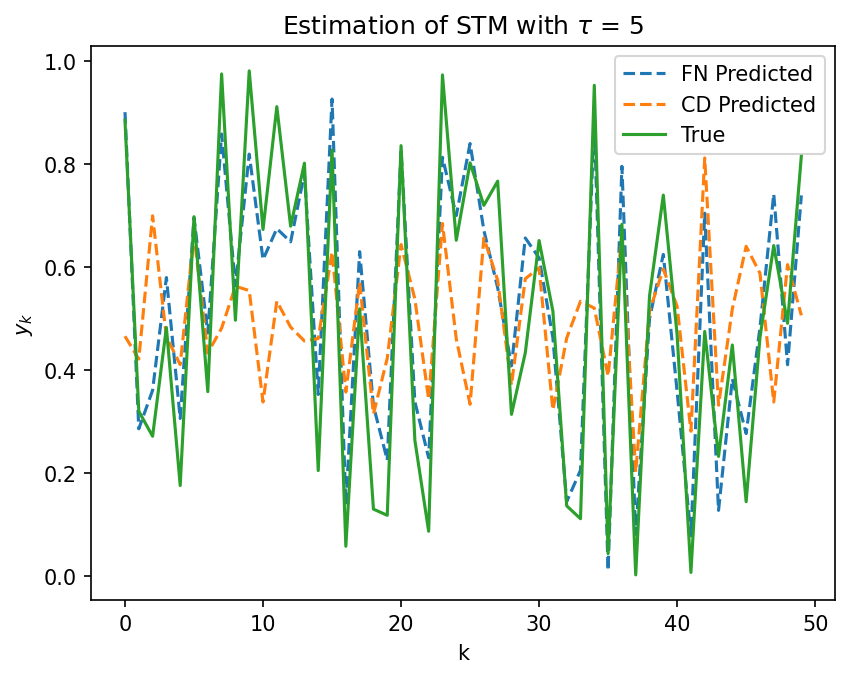

In [134]:
fig, ax = stm_task.plotTimeSeriesEstimate(tau, fn_tau_params, cd_tau_params)
ax.set_title(r'Estimation of STM with $\tau$ = ' + f'{tau}')
ax.set_ylabel(r'$y_k$')

Visualising score over range of tau

In [135]:
taus = np.arange(1, 201)

Text(0.5, 1.0, 'STM performance as a function of time delay')

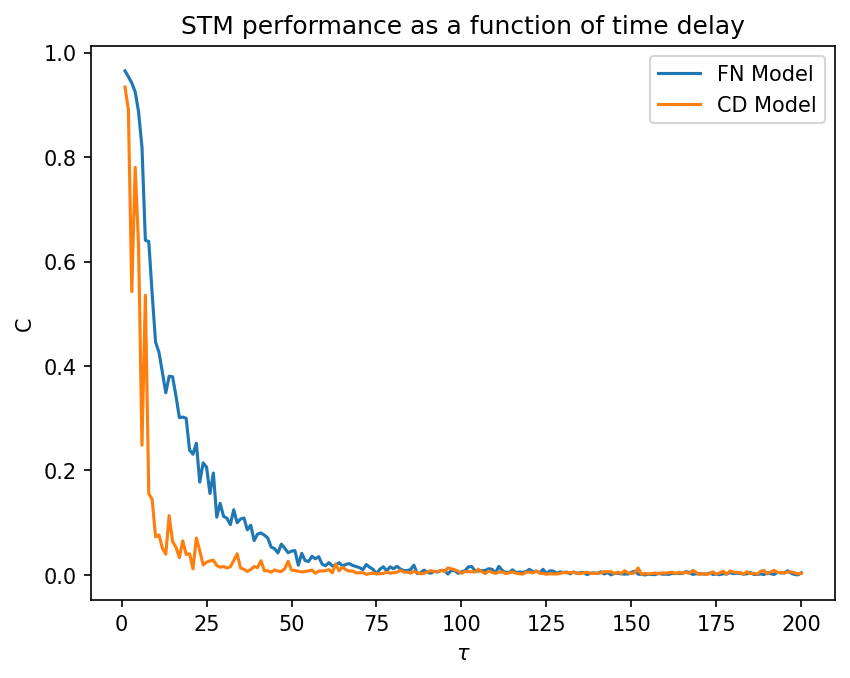

In [136]:
fig, ax = stm_task.plotPerfVsSettings(taus)
ax.set_xlabel(r'$\tau$')
ax.set_title('STM performance as a function of time delay')

In [137]:
list(regimes.values())[0] + (cd_gammas[0],)

(10, 0.01, 0.01)

In [138]:
x_tr_cd.keys()

dict_keys([(10, 0.01, 0.01), (1, 1, 0.01), (0.01, 10, 0.01), (10, 0.01, 0.1), (1, 1, 0.1), (0.01, 10, 0.1), (10, 0.01, 1), (1, 1, 1), (0.01, 10, 1)])

In [139]:
from sklearn.linear_model import Ridge

def generateScores(func, vals):

    markovian_scores = []
    intermediate_scores = []
    nonmarkovian_scores = []

    for val in vals:
        markovian_scores.append([])
        intermediate_scores.append([])
        nonmarkovian_scores.append([])
        f = func(val, s)
        y_tr, y_te = getYData(f)

        reg_fn = LinearRegression().fit(x_tr_fn[regimes['markov']], y_tr)
        y_pred_fn = reg_fn.predict(x_te_fn[regimes['markov']])
        markovian_scores[-1].append(memory_capacity(y_te, y_pred_fn))

        reg_fn = LinearRegression().fit(x_tr_fn[regimes['intermediate']], y_tr)
        y_pred_fn = reg_fn.predict(x_te_fn[regimes['intermediate']])
        intermediate_scores[-1].append(memory_capacity(y_te, y_pred_fn))

        reg_fn = LinearRegression().fit(x_tr_fn[regimes['nonmarkov']], y_tr)
        y_pred_fn = reg_fn.predict(x_te_fn[regimes['nonmarkov']])
        nonmarkovian_scores[-1].append(memory_capacity(y_te, y_pred_fn))

        caps = []
        for gamma in cd_gammas:
            reg_cd = LinearRegression().fit(x_tr_cd[list(regimes.values())[0] + (gamma,)], y_tr)
            y_pred_cd1 = reg_cd.predict(x_te_cd[list(regimes.values())[0] + (gamma,)])
            caps.append(memory_capacity(y_te, y_pred_cd1))
        markovian_scores[-1].append(max(caps))

        caps = []
        for gamma in cd_gammas:
            reg_cd = LinearRegression().fit(x_tr_cd[list(regimes.values())[1] + (gamma,)], y_tr)
            y_pred_cd1 = reg_cd.predict(x_te_cd[list(regimes.values())[1] + (gamma,)])
            caps.append(memory_capacity(y_te, y_pred_cd1))
        intermediate_scores[-1].append(max(caps))

        caps = []
        for gamma in cd_gammas:
            reg_cd = LinearRegression().fit(x_tr_cd[list(regimes.values())[2] + (gamma,)], y_tr)
            y_pred_cd1 = reg_cd.predict(x_te_cd[list(regimes.values())[2] + (gamma,)])
            caps.append(memory_capacity(y_te, y_pred_cd1))
        nonmarkovian_scores[-1].append(max(caps))

    return markovian_scores, intermediate_scores, nonmarkovian_scores


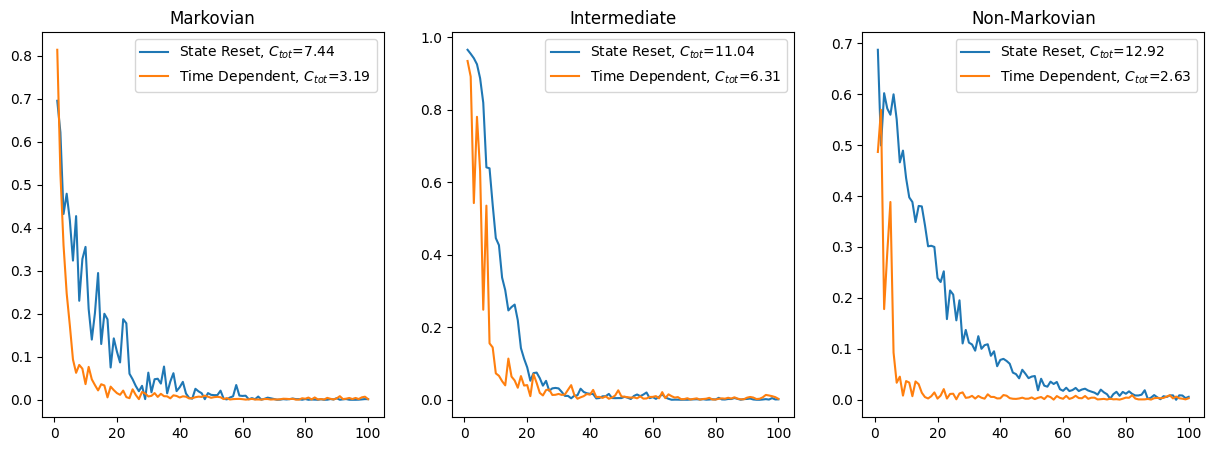

In [140]:
taus = np.arange(1, 101)
markovian_scores, intermediate_scores, nonmarkovian_scores = generateScores(STM, taus)

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(15,5))

ax1.set_title('Markovian')
ax1.plot(taus, np.array(markovian_scores))
ax1.legend(['State Reset, $C_{tot}$='+str(np.round(np.sum(np.array(markovian_scores).T[0]),2)), 'Time Dependent, $C_{tot}$='+str(np.round(np.sum(np.array(markovian_scores).T[1]),2))])

ax2.set_title('Intermediate')
ax2.plot(taus, np.array(intermediate_scores))
ax2.legend(['State Reset', 'Time Dependent'])
ax2.legend(['State Reset, $C_{tot}$='+str(np.round(np.sum(np.array(intermediate_scores).T[0]),2)), 'Time Dependent, $C_{tot}$='+str(np.round(np.sum(np.array(intermediate_scores).T[1]),2))])

ax3.set_title('Non-Markovian')
ax3.plot(taus, np.array(nonmarkovian_scores))
ax3.legend(['State Reset', 'Time Dependent'])
ax3.legend(['State Reset, $C_{tot}$='+str(np.round(np.sum(np.array(nonmarkovian_scores).T[0]),2)), 'Time Dependent, $C_{tot}$='+str(np.round(np.sum(np.array(nonmarkovian_scores).T[1]),2))])

#### 6.2.2 Performance on NARMA task

In [84]:
fn_narma_params = (0.01,10)
cd_narma_params = (0.01,10,0.1)

In [85]:
n = 10
narma_task = RCTask(narma)

FN Capacity: 0.4149694061449054
CD Capacity: 1.713445580897295e-05


(<Figure size 960x720 with 1 Axes>, <Axes: xlabel='k'>)

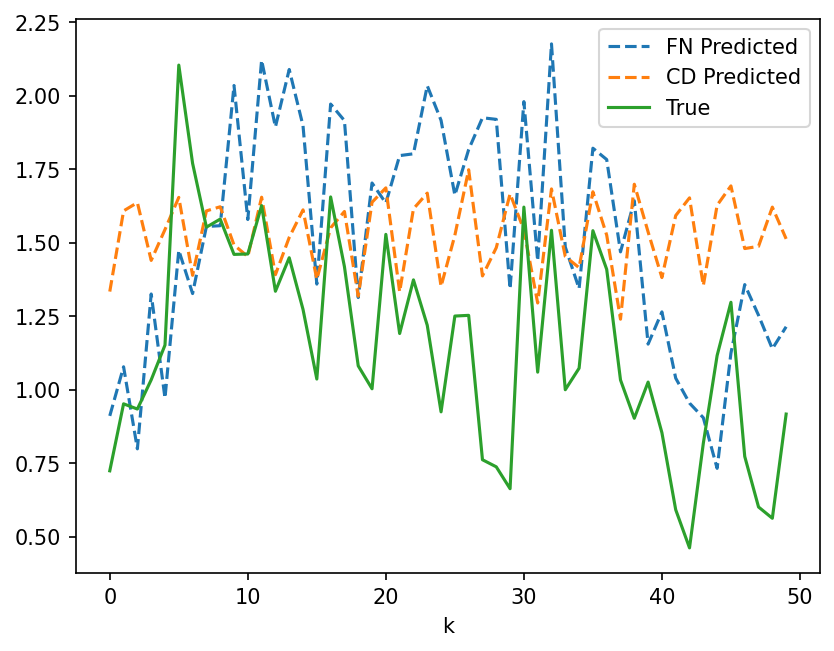

In [86]:
narma_task.plotTimeSeriesEstimate(n, fn_narma_params, cd_narma_params)

In [87]:
ns = np.arange(1, 21)

(<Figure size 960x720 with 1 Axes>, <Axes: ylabel='C'>)

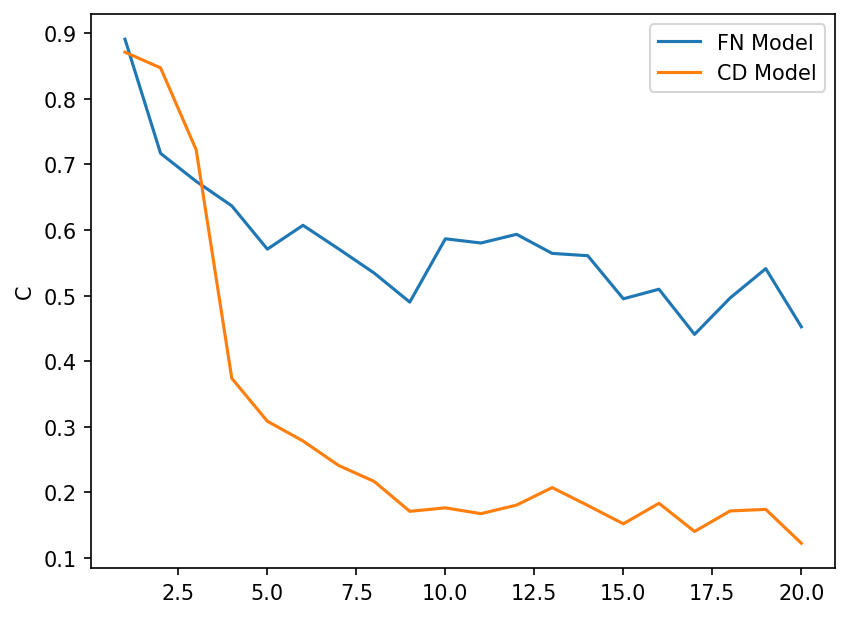

In [88]:
narma_task.plotPerfVsSettings(ns)

In [89]:
ns = np.arange(1, 41)

In [90]:
markovian_scores, intermediate_scores, nonmarkovian_scores = generateScores(narma, ns)

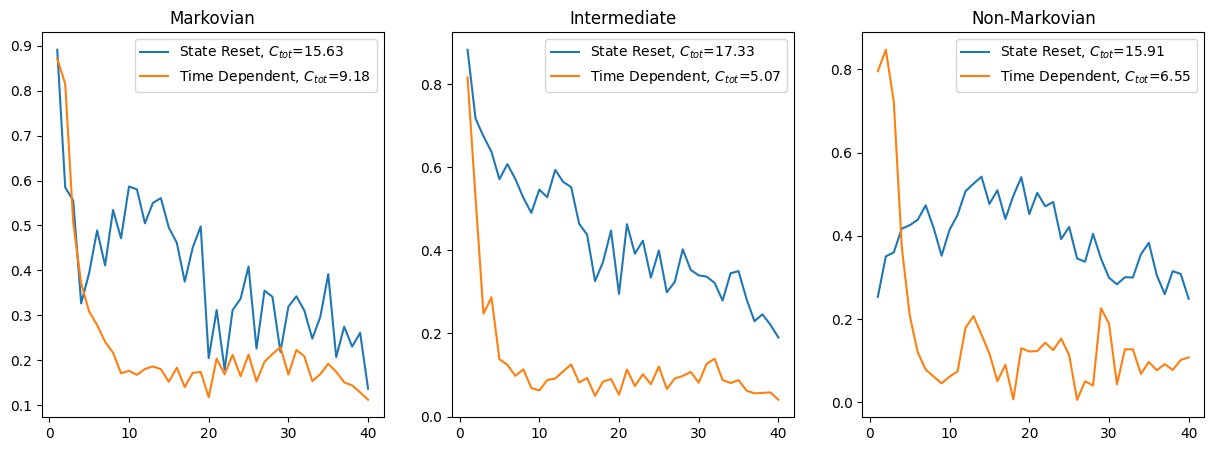

In [91]:


fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(15,5))

ax1.set_title('Markovian')
ax1.plot(ns, np.array(markovian_scores))
ax1.legend(['State Reset, $C_{tot}$='+str(np.round(np.sum(np.array(markovian_scores).T[0]),2)), 'Time Dependent, $C_{tot}$='+str(np.round(np.sum(np.array(markovian_scores).T[1]),2))])

ax2.set_title('Intermediate')
ax2.plot(ns, np.array(intermediate_scores))
ax2.legend(['State Reset', 'Time Dependent'])
ax2.legend(['State Reset, $C_{tot}$='+str(np.round(np.sum(np.array(intermediate_scores).T[0]),2)), 'Time Dependent, $C_{tot}$='+str(np.round(np.sum(np.array(intermediate_scores).T[1]),2))])

ax3.set_title('Non-Markovian')
ax3.plot(ns, np.array(nonmarkovian_scores))
ax3.legend(['State Reset', 'Time Dependent'])
ax3.legend(['State Reset, $C_{tot}$='+str(np.round(np.sum(np.array(nonmarkovian_scores).T[0]),2)), 'Time Dependent, $C_{tot}$='+str(np.round(np.sum(np.array(nonmarkovian_scores).T[1]),2))])

#### 6.2.3 Performance on Parity task

In [92]:
fn_parity_params = (1,1)
cd_parity_params = stmParamsCd(1)

In [93]:
ptau = 3
parity_task = RCTask(parity)

In [94]:
parity_task.plotTimeSeriesEstimate(ptau, fn_parity_params, cd_parity_params)

KeyError: (0.1, 10, 1)

In [ ]:
ptaus = np.arange(1, 6)

(<Figure size 960x720 with 1 Axes>, <Axes: ylabel='C'>)

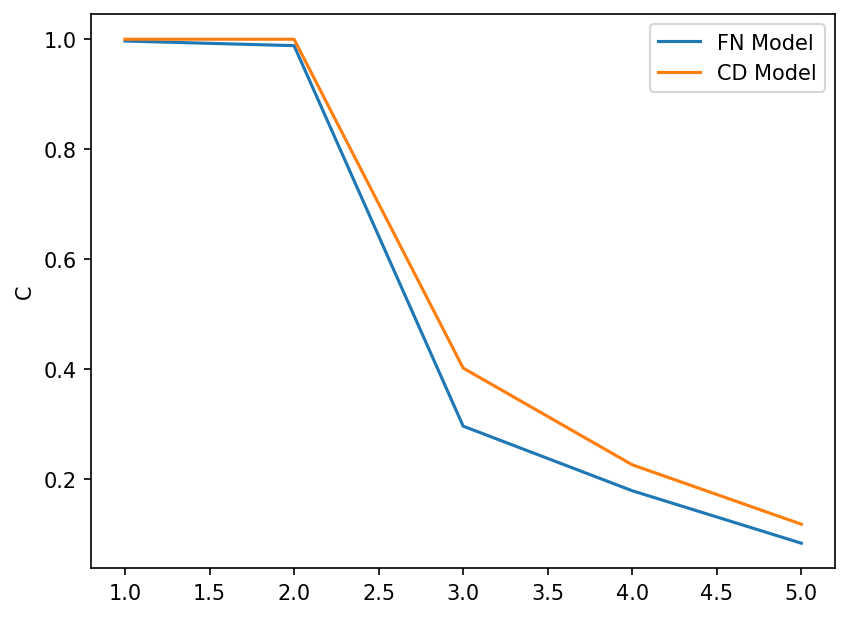

In [ ]:
parity_task.plotPerfVsSettings(ptaus)

#### 6.2.4 Performance on Polynomial task

In [ ]:
fn_poly_params = (1,1)
cd_poly_params = stmParamsCd(5)

In [ ]:
n = 5
poly_task = RCTask(polynomial_exp)

FN Capacity: 0.9093881684509393
CD Capacity: 0.9786549845004063


(<Figure size 960x720 with 1 Axes>, <Axes: xlabel='k'>)

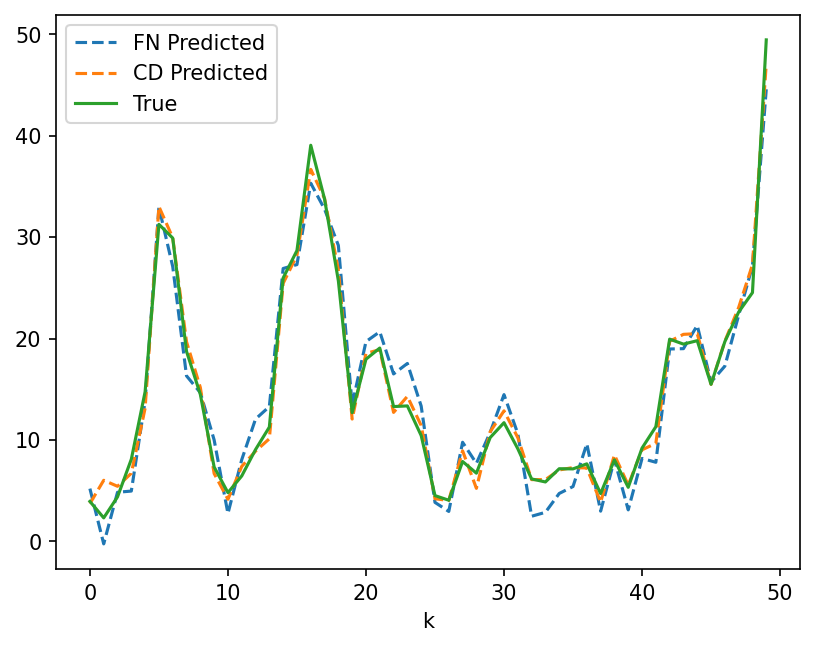

In [ ]:
poly_task.plotTimeSeriesEstimate(n, fn_poly_params, cd_poly_params)

In [ ]:
ns = np.arange(1, 21)

(<Figure size 960x720 with 1 Axes>, <Axes: ylabel='C'>)

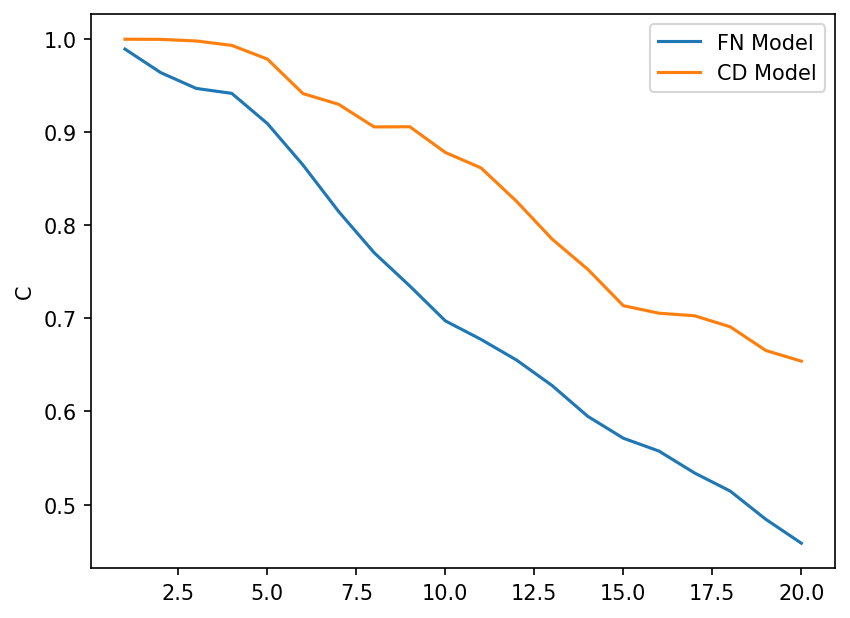

In [ ]:
poly_task.plotPerfVsSettings(ns)

#### 6.2.5 Performance on Tomography task

In [ ]:
fn_tomo_params = fn_params[1]
cd_tomo_params = cd_params[1]

In [ ]:
n = 4
tomo_n = tomography(n, s)

In [ ]:
y_tr_tomo, y_te_tomo = getYData(tomo_n)

In [ ]:
reg_fn_tomo = LinearRegression().fit(x_tr_fn[fn_tomo_params], y_tr_tomo)
reg_cd_tomo = LinearRegression().fit(x_tr_cd[cd_tomo_params], y_tr_tomo)

In [ ]:
y_pred_fn = reg_fn_tomo.predict(x_te_fn[fn_tomo_params])
y_pred_cd = reg_cd_tomo.predict(x_te_cd[cd_tomo_params])

In [ ]:
rho_pred_fn = [DensityMatrix(vec_to_density_matrix(row)) for row in y_pred_fn]
rho_pred_cd = [DensityMatrix(vec_to_density_matrix(row)) for row in y_pred_cd]

rho_true = [DensityMatrix(vec_to_density_matrix(row)) for row in y_te_tomo]

In [ ]:
import numpy as np
from scipy.linalg import sqrtm

def fidelity(rho, sigma):

    # sqrt(rho)
    sqrt_rho = sqrtm(rho)

    # sqrt(rho) sigma sqrt(rho)
    inner = sqrt_rho @ sigma @ sqrt_rho

    # sqrt of that
    sqrt_inner = sqrtm(inner)

    # trace
    F = np.trace(sqrt_inner)

    # Numerical noise can introduce tiny imaginary parts
    return float(np.real(F)**2)

In [ ]:
fid_fn = np.mean([fidelity(state.state, state_pred.state) for state, state_pred in zip(rho_true, rho_pred_fn)])
fid_cd = np.mean([fidelity(state.state, state_pred.state) for state, state_pred in zip(rho_true, rho_pred_cd)])

/var/folders/8g/jdythvzn5njbj6km21j0m2080000gn/T/ipykernel_17159/3722345052.py:7: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sqrt_rho = sqrtm(rho)


In [ ]:
print(f'Fidelity FN: {fid_fn}')
print(f'Fidelity CD: {fid_cd}')

Fidelity FN: 0.8592881743152908
Fidelity CD: 0.9297194301401996
